In [1]:
#Carga de datos de prueba
import pandas as pd
df = pd.read_csv("../data/raw/fraudTest.csv")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  object 
 2   cc_num                 555719 non-null  int64  
 3   merchant               555719 non-null  object 
 4   category               555719 non-null  object 
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  object 
 7   last                   555719 non-null  object 
 8   gender                 555719 non-null  object 
 9   street                 555719 non-null  object 
 10  city                   555719 non-null  object 
 11  state                  555719 non-null  object 
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64
 14  long                   555719 non-nu

In [3]:
#Corrigiendo el tipo de dato
df['trans_date_trans_time']=df['trans_date_trans_time'].astype('datetime64[ns]')
df['dob']=df['dob'].astype('datetime64[ns]')

In [4]:
#Mostrando las primeras filas del DataFrame
df.head(5)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [5]:
#Verificando valores duplicados
print("Filas duplicadas: " , df.duplicated().sum())

print("Valores duplicados en transaccion: ", df['trans_num'].duplicated().sum())

Filas duplicadas:  0
Valores duplicados en transaccion:  0


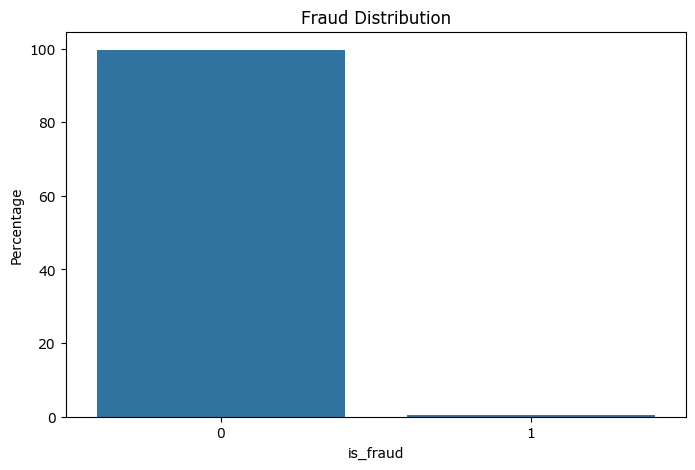

In [6]:
#Visualizando el porcentaje de fraude

import seaborn as sns
import matplotlib.pyplot as plt

fraud_dist= df['is_fraud'].value_counts()
fraud_dist = fraud_dist / fraud_dist.sum() * 100
fraud_dist = fraud_dist.reset_index()
fraud_dist.columns = ['is_fraud', 'percentage']

plt.figure(figsize=(8, 5))
sns.barplot(x='is_fraud', y='percentage', data=fraud_dist)
plt.title('Fraud Distribution')
plt.xlabel('is_fraud')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.show()


* Se aprecia el enorme desequilibrio de clases, mas del 95% de los datos tiene la tendencia para no ser fraudelentos.

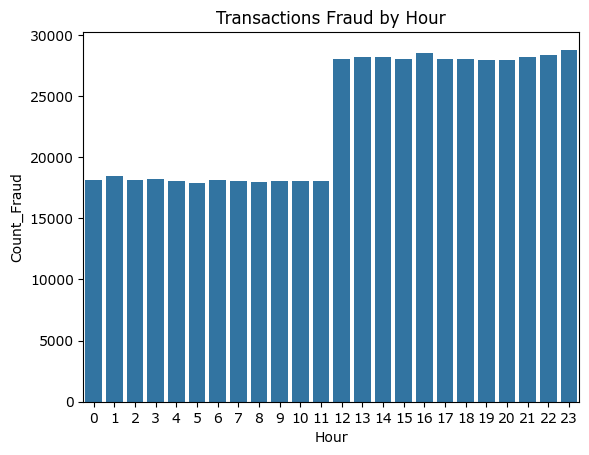

In [7]:
#Analisis temporal por hora

df['transaction_hour'] = df['trans_date_trans_time'].dt.hour
df_hour_trans = df.groupby('transaction_hour')['is_fraud'].count().reset_index()
df_hour_trans.columns = ['transaction_hour', 'count_fraud']

sns.barplot(x="transaction_hour", y="count_fraud", data=df_hour_trans)
plt.title("Transactions Fraud by Hour")
plt.xlabel("Hour")
plt.ylabel("Count_Fraud")
plt.show()


* Se muestra la tendencia de las transacciones apartir del medio dia hasta las 23:59 horas.

C:\Users\Paulo God\AppData\Local\Temp\ipykernel_3828\2754611796.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_day_trans["transaction_day_week"].replace(day_week_map, inplace=True)


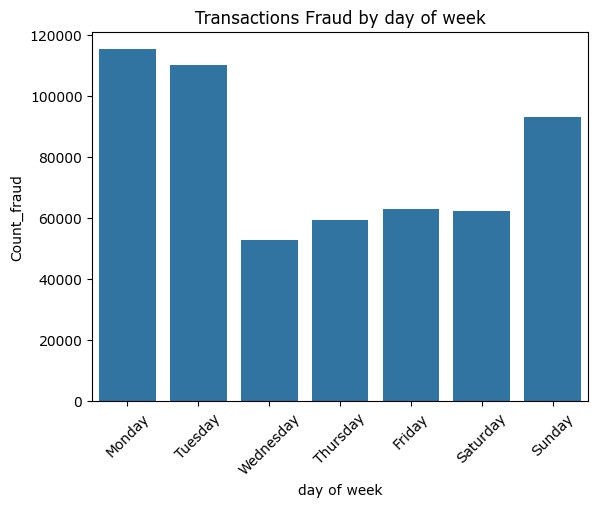

In [8]:
#Analisis temporal por dia
df['transaction_day_week'] = df['trans_date_trans_time'].dt.dayofweek
df_day_trans = df.groupby('transaction_day_week')['is_fraud'].count().reset_index()

day_week_map = {
   
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday"
    }

df_day_trans["transaction_day_week"].replace(day_week_map, inplace=True)

sns.barplot(x="transaction_day_week", y="is_fraud", data=df_day_trans)
plt.xticks(rotation=45)
plt.title("Transactions Fraud by day of week")
plt.xlabel("day of week")
plt.ylabel("Count_fraud")
plt.show()


* Se muestra la prefencia de los fines de semana y los primeros dias para las transacciones fraudulentas.

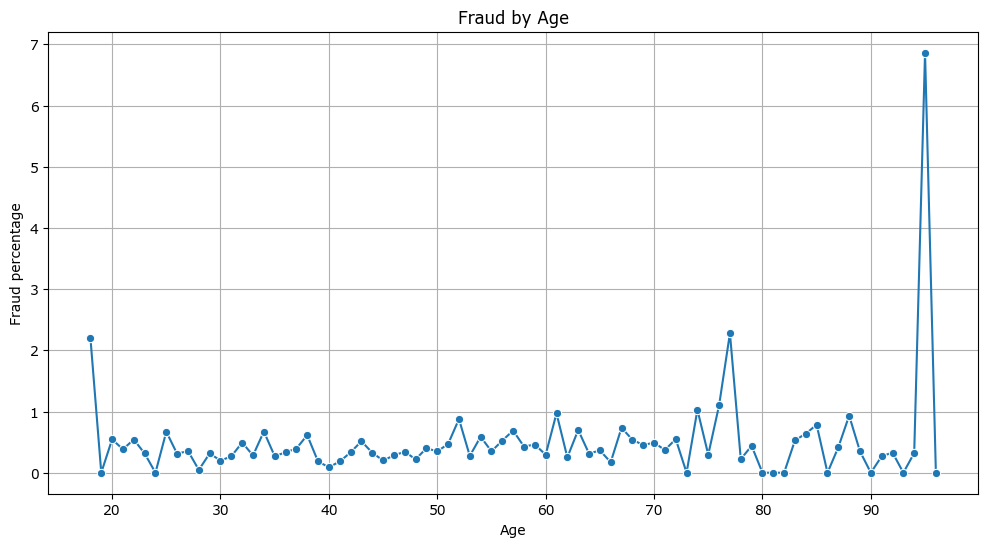

In [9]:
# Calcular edad con validaciones
df['transaction_date'] = pd.to_datetime(df['trans_date_trans_time'].dt.date)
df['age']=((df['transaction_date'] - df['dob']).dt.days // 365)

df_valid = df[(df['age'] >= 18) & (df['age'] <= 100)]
age_fraud_rate = df_valid.groupby('age')['is_fraud'].agg(
    total_fraud ='count',
    fraud = 'sum'
).reset_index()

age_fraud_rate['rate_fraud'] = (age_fraud_rate['fraud'] / age_fraud_rate['total_fraud']) * 100

plt.figure(figsize=(12, 6))
sns.lineplot(x='age', y='rate_fraud', data=age_fraud_rate, marker='o')
plt.grid()
plt.title('Fraud by Age')
plt.xlabel('Age')
plt.ylabel('Fraud percentage')
plt.show()

* Se muestra la tasa de fraudes de todas las transacciones hechas por las diferentes edades de personas.

C:\Users\Paulo God\AppData\Local\Temp\ipykernel_3828\370482704.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  volume_by_age_group = df.groupby("age_group").size().reset_index(name="total_transactions").sort_values("age_group")


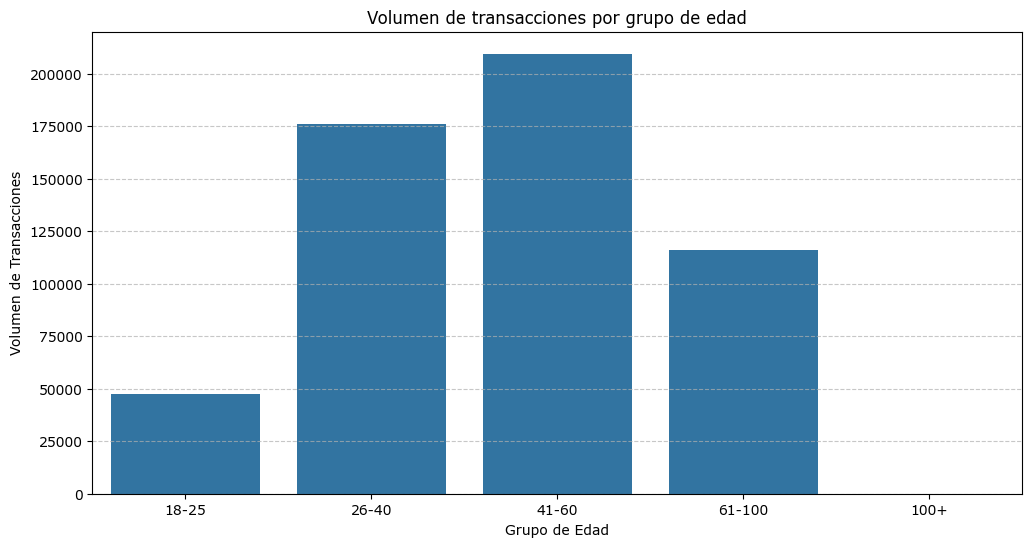

In [10]:
# Crear rangos de edad
import numpy as np

bins = [18, 25, 40, 60, 100, np.inf]
labels = ["18-25", "26-40", "41-60", "61-100", "100+"]
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, include_lowest=True)

# Agregar por grupo de edad
volume_by_age_group = df.groupby("age_group").size().reset_index(name="total_transactions").sort_values("age_group")


# Graficar
plt.figure(figsize=(12, 6))
sns.barplot(x="age_group", y="total_transactions", data=volume_by_age_group)
plt.title("Volumen de transacciones por grupo de edad")
plt.xlabel("Grupo de Edad")
plt.ylabel("Volumen de Transacciones")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

* A partir del gráfico anterior, se observa que el mayor volumen de transacciones se concentra en el rango de edad entre los 20 y 60 años, lo cual es consistente con la población económicamente activa. Sin embargo, también se evidencian valores atípicos y elevados en los extremos del rango etario. Específicamente, en el grupo de 18 a 20 años, podrían registrarse más transacciones fraudulentas, posiblemente debido a un menor interés o experiencia de los usuarios jóvenes en la revisión y gestión de sus cuentas bancarias. Del mismo modo, en personas de mayor edad, los fraudes podrían estar asociados a la suplantación de identidad, aprovechando su menor familiaridad con tecnologías digitales. Estos hallazgos sugieren que tanto los usuarios más jóvenes como los mayores son segmentos más vulnerables al fraude financiero.

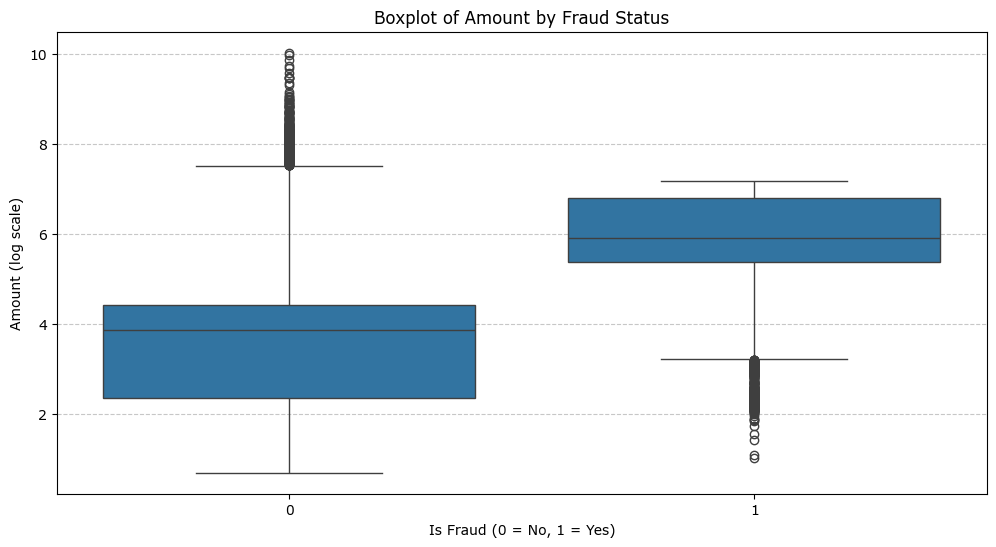

In [17]:
# Box plot de la variable amt
df['log_amt'] = np.log1p(df['amt'])  # Aplicar logaritmo para manejar valores extremos
plt.figure(figsize=(12,6))
sns.boxplot(
    x='is_fraud',
    y='log_amt',
    data=df,
    showfliers=True
)
plt.title('Boxplot of Amount by Fraud Status')
plt.xlabel('Is Fraud (0 = No, 1 = Yes)')
plt.ylabel('Amount (log scale)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

* Se muestra el diagrama de caja con los valores de la mediana mas altos en fraude y valores atipicos menores, esto nos sugiere que los valores atipicos pueden ser prubeas de los fraudes en razon de probar si la operacion fue exitosa antes de realizar una operacion de un monto mayor, tambien que el valor medio es mas alto en comparacion a las transacciones normales, en las transacciones normales si notamos valores atipicos de muy alto valor, por lo cual hay que tomar enfasis en la media y valores pequeños antes de una transaaccion fraudulenta.

C:\Users\Paulo God\AppData\Local\Temp\ipykernel_3828\3744970487.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='category', data=non_fraud_categories.head(10), palette='viridis')


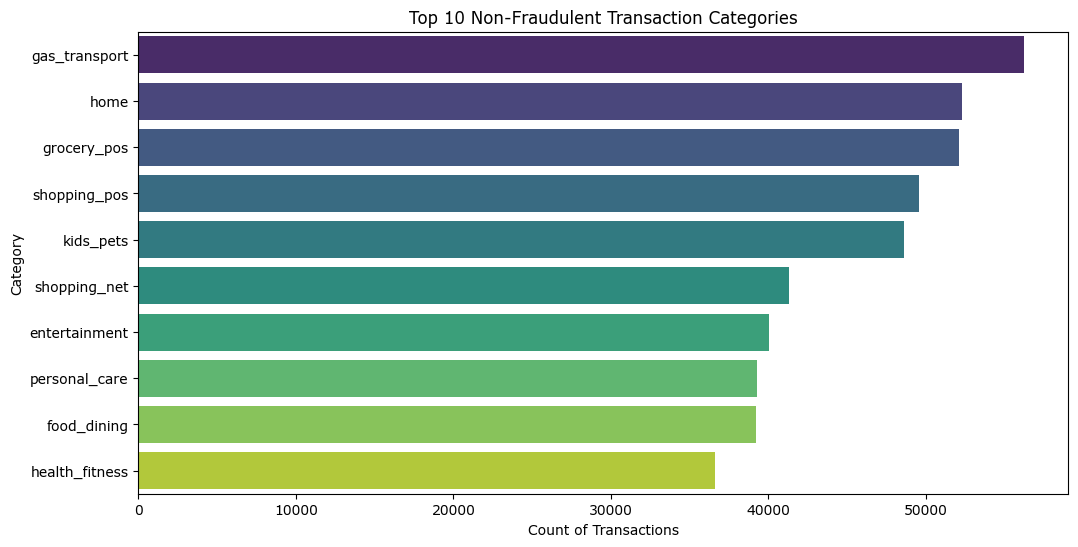

In [12]:
#Categorias con mayor numero de transacciones no fraudulentas
non_fraud_categories = df[df['is_fraud'] == 0]['category'].value_counts().reset_index()
non_fraud_categories.columns = ['category', 'count']
non_fraud_categories = non_fraud_categories.sort_values(by='count', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='count', y='category', data=non_fraud_categories.head(10), palette='viridis')
plt.title('Top 10 Non-Fraudulent Transaction Categories')
plt.xlabel('Count of Transactions')
plt.ylabel('Category')
plt.show()


C:\Users\Paulo God\AppData\Local\Temp\ipykernel_3828\2204393127.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


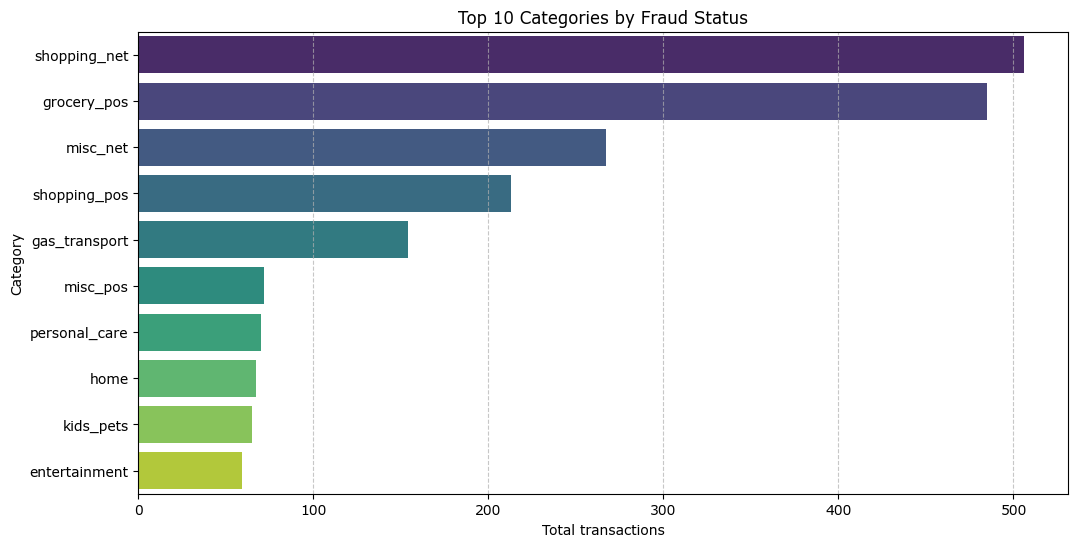

In [13]:
fraud_transaccions = df[df['is_fraud'] == 1]
most_category_fraud = fraud_transaccions.value_counts('category').reset_index(name='count').sort_values(by='count', ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(
    x='count',
    y='category',
    data=most_category_fraud.head(10),
    palette='viridis'
)
plt.title('Top 10 Categories by Fraud Status')
plt.xlabel('Total transactions')
plt.ylabel('Category')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [2]:
df['category'].value_counts(
)

category
gas_transport     56370
grocery_pos       52553
home              52345
shopping_pos      49791
kids_pets         48692
shopping_net      41779
entertainment     40104
personal_care     39327
food_dining       39268
health_fitness    36674
misc_pos          34574
misc_net          27367
grocery_net       19426
travel            17449
Name: count, dtype: int64

* Con los resultados de los 2 graficos podemos notar algo claro, que apesar de tener unas transacciones por debajo de la mitad de nuestro ranking, 'Shopping_net'tiene la mayor concentraccion de fraude, teniendo claro que esta categoria es la mas facil de vulnerar, tambien que misc_net tiene la 3ra concentracion mas alta pero no aparece dentro de las 10 transacciones no fraudelentas. de igual maner misc_pos pero en menor cantidad, indicando que estas categorias tienen un bajo numero de transacciones tienen indices mayores de fraude.